In [5]:
!pip install fastapi uvicorn numpy pandas scikit-learn sentence-transformers faiss-cpu scikit-fuzzy umap-learn matplotlib

In [1]:
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(
    subset="all",
    remove=("headers","footers","quotes")
)

documents = dataset.data
labels = dataset.target

print("Total documents:", len(documents))

Total documents: 18846


In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

(18846, 384)


In [3]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("Vectors stored:", index.ntotal)

Vectors stored: 18846


In [4]:
import skfuzzy as fuzz

embedding_T = embeddings.T

clusters = 10

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    embedding_T,
    clusters,
    2,
    error=0.005,
    maxiter=1000
)

print("Cluster centers:", cntr.shape)

Cluster centers: (10, 384)


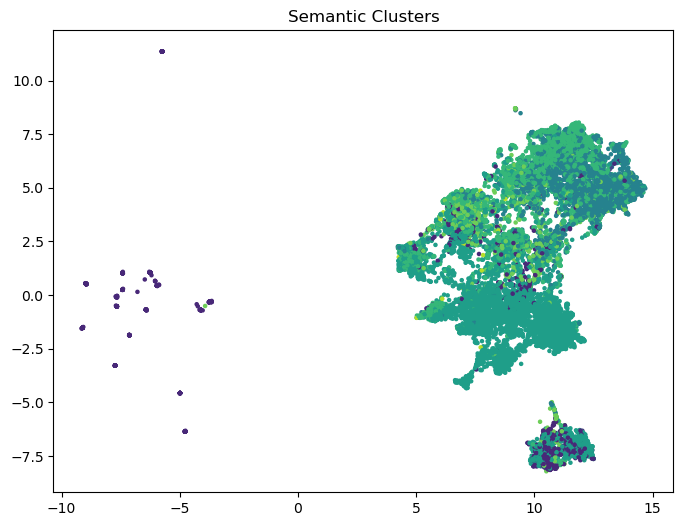

In [5]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP()

reduced = reducer.fit_transform(embeddings)

labels = u.argmax(axis=0)

plt.figure(figsize=(8,6))
plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=labels,
    s=5
)

plt.title("Semantic Clusters")
plt.show()

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

class SemanticCache:
    
    def __init__(self, threshold=0.85):
        self.entries = []
        self.threshold = threshold
        self.hit = 0
        self.miss = 0
        
    def lookup(self, vector):
        
        for entry in self.entries:
            
            sim = cosine_similarity(
                [vector],
                [entry["vector"]]
            )[0][0]
            
            if sim >= self.threshold:
                self.hit += 1
                return True, entry, sim
        
        self.miss += 1
        return False, None, None
    
    def add(self, query, vector, result):
        
        self.entries.append({
            "query": query,
            "vector": vector,
            "result": result
        })

In [7]:
def search_query(query):
    
    q_vector = model.encode([query])[0]
    
    hit, entry, sim = cache.lookup(q_vector)
    
    if hit:
        print("Cache HIT")
        return entry["result"]
    
    print("Cache MISS")
    
    q_vector_np = np.array([q_vector])
    
    distances, indices = index.search(q_vector_np, 3)
    
    results = [documents[i] for i in indices[0]]
    
    result_text = "\n".join(results)
    
    cache.add(query, q_vector, result_text)
    
    return result_text

In [8]:
cache = SemanticCache()

print(search_query("gun control laws"))


Cache MISS


But this is all gun control laws end up doing.  Politicians can never
manage to get a handle on those who obtain arms illegally, so all their
laws can ever do is further restrict people who obtain them legally.

Karen McNutt, a local attorney, states that there are about two MILLION
licensed gun owners in Massachusetts.  In the past year, the number of
licensed gun owners involved in gun crimes was something like SIX.
Yet, there were a large number of gun crimes in the state last year.

Does passing laws that will further restricting only those people ALREADY
obeying laws pay any dividents?


So far, I've seen them treated with the least respect by legislators.


See, this is what I call the "argument from religion:" "I believe."  Don't
believe -- it's not NECESSARY to take this on faith.  Go look at the history
of countries that passed gun restrictions.  Pay particular attention to
whether or not violent crime was HIGHER before the restrictions and LOWER
after.  (Don't lo

In [9]:
!uvicorn main:app --reload

^C
